In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='whitegrid')

print("✅ Imports done")

✅ Imports done


In [8]:
# Paths
SALES_PATH   = '../data/raw/sales_train_validation.csv'
PRICES_PATH  = '../data/raw/sell_prices.csv'
CALENDAR_PATH= '../data/raw/calendar.csv'

# Load
sales    = pd.read_csv(SALES_PATH)
prices   = pd.read_csv(PRICES_PATH)
calendar = pd.read_csv(CALENDAR_PATH)

print(f"Sales shape:    {sales.shape}")
print(f"Prices shape:   {prices.shape}")
print(f"Calendar shape: {calendar.shape}")

Sales shape:    (30490, 1919)
Prices shape:   (6841121, 4)
Calendar shape: (1969, 14)


In [9]:
# First 5 rows, first 10 columns
print("=== SALES (first 10 cols) ===")
print(sales.iloc[:, :10].head())

print("\n=== Column types ===")
print(sales.dtypes[:10])

print("\n=== ID columns ===")
id_cols = ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']
print(sales[id_cols].head(10))

print("\n=== Unique counts ===")
for col in id_cols:
    print(f"  {col}: {sales[col].nunique()} unique values")

=== SALES (first 10 cols) ===
                              id        item_id    dept_id   cat_id store_id  \
0  HOBBIES_1_001_CA_1_validation  HOBBIES_1_001  HOBBIES_1  HOBBIES     CA_1   
1  HOBBIES_1_002_CA_1_validation  HOBBIES_1_002  HOBBIES_1  HOBBIES     CA_1   
2  HOBBIES_1_003_CA_1_validation  HOBBIES_1_003  HOBBIES_1  HOBBIES     CA_1   
3  HOBBIES_1_004_CA_1_validation  HOBBIES_1_004  HOBBIES_1  HOBBIES     CA_1   
4  HOBBIES_1_005_CA_1_validation  HOBBIES_1_005  HOBBIES_1  HOBBIES     CA_1   

  state_id  d_1  d_2  d_3  d_4  
0       CA    0    0    0    0  
1       CA    0    0    0    0  
2       CA    0    0    0    0  
3       CA    0    0    0    0  
4       CA    0    0    0    0  

=== Column types ===
id            str
item_id       str
dept_id       str
cat_id        str
store_id      str
state_id      str
d_1         int64
d_2         int64
d_3         int64
d_4         int64
dtype: object

=== ID columns ===
                              id        item_id    dept

In [10]:
print("=== CALENDAR ===")
print(calendar.head(10).to_string())

print("\n=== Calendar columns ===")
print(calendar.dtypes)

print("\n=== Event types in the data ===")
print(calendar['event_type_1'].value_counts(dropna=False))

=== CALENDAR ===
         date  wm_yr_wk    weekday  wday  month  year     d event_name_1 event_type_1 event_name_2 event_type_2  snap_CA  snap_TX  snap_WI
0  2011-01-29     11101   Saturday     1      1  2011   d_1          NaN          NaN          NaN          NaN        0        0        0
1  2011-01-30     11101     Sunday     2      1  2011   d_2          NaN          NaN          NaN          NaN        0        0        0
2  2011-01-31     11101     Monday     3      1  2011   d_3          NaN          NaN          NaN          NaN        0        0        0
3  2011-02-01     11101    Tuesday     4      2  2011   d_4          NaN          NaN          NaN          NaN        1        1        0
4  2011-02-02     11101  Wednesday     5      2  2011   d_5          NaN          NaN          NaN          NaN        1        0        1
5  2011-02-03     11101   Thursday     6      2  2011   d_6          NaN          NaN          NaN          NaN        1        1        1
6  2011-02

In [11]:
print("=== PRICES ===")
print(prices.head(10))
print(f"\nDate range (wm_yr_wk): {prices['wm_yr_wk'].min()} → {prices['wm_yr_wk'].max()}")
print(f"Price range: ${prices['sell_price'].min():.2f} → ${prices['sell_price'].max():.2f}")
print(f"Missing prices: {prices['sell_price'].isna().sum()}")

=== PRICES ===
  store_id        item_id  wm_yr_wk  sell_price
0     CA_1  HOBBIES_1_001     11325        9.58
1     CA_1  HOBBIES_1_001     11326        9.58
2     CA_1  HOBBIES_1_001     11327        8.26
3     CA_1  HOBBIES_1_001     11328        8.26
4     CA_1  HOBBIES_1_001     11329        8.26
5     CA_1  HOBBIES_1_001     11330        8.26
6     CA_1  HOBBIES_1_001     11331        8.26
7     CA_1  HOBBIES_1_001     11332        8.26
8     CA_1  HOBBIES_1_001     11333        8.26
9     CA_1  HOBBIES_1_001     11334        8.26

Date range (wm_yr_wk): 11101 → 11621
Price range: $0.01 → $107.32
Missing prices: 0


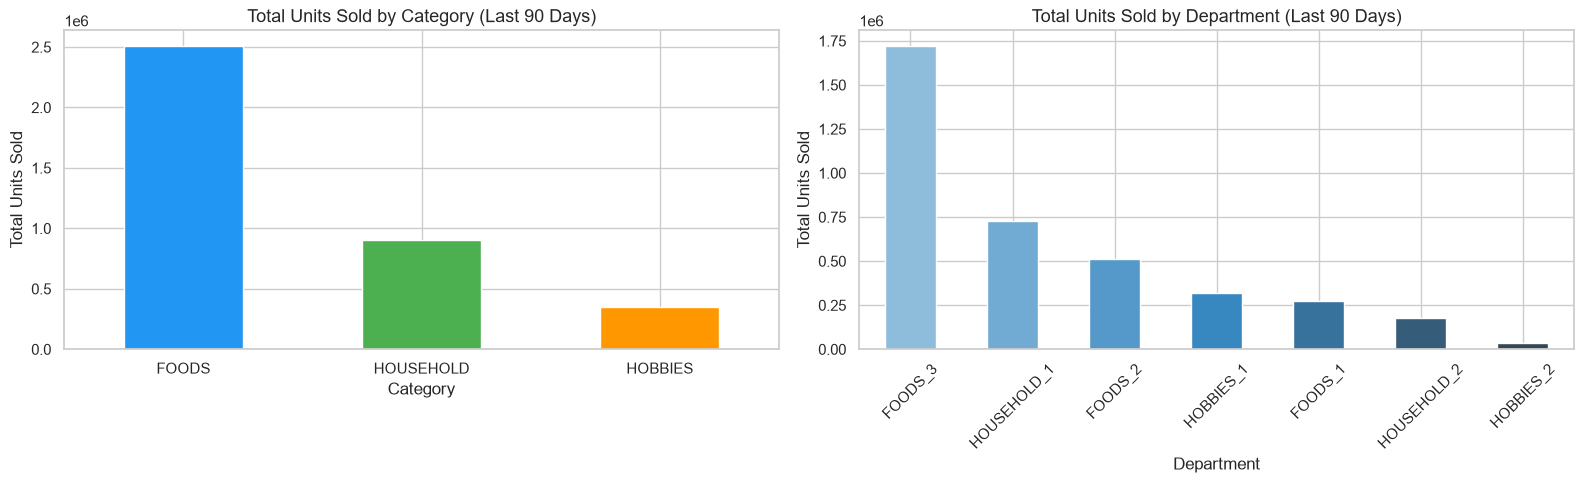

✅ Saved to outputs/shap_plots/


In [12]:
# Melt to long format for just the last 90 days (faster)
day_cols = [f'd_{i}' for i in range(1824, 1914)]  # last 90 days
id_cols  = ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']

sales_tail = sales[id_cols + day_cols].copy()
sales_long = sales_tail.melt(id_vars=id_cols, var_name='d', value_name='units_sold')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1 — Total sales by category
cat_sales = sales_long.groupby('cat_id')['units_sold'].sum().sort_values(ascending=False)
cat_sales.plot(kind='bar', ax=axes[0], color=['#2196F3','#4CAF50','#FF9800'])
axes[0].set_title('Total Units Sold by Category (Last 90 Days)', fontsize=13)
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Total Units Sold')
axes[0].tick_params(axis='x', rotation=0)

# Plot 2 — Sales by department
dept_sales = sales_long.groupby('dept_id')['units_sold'].sum().sort_values(ascending=False)
dept_sales.plot(kind='bar', ax=axes[1], color=sns.color_palette('Blues_d', len(dept_sales)))
axes[1].set_title('Total Units Sold by Department (Last 90 Days)', fontsize=13)
axes[1].set_xlabel('Department')
axes[1].set_ylabel('Total Units Sold')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../outputs/shap_plots/01_sales_by_category.png', bbox_inches='tight')
plt.show()
print("✅ Saved to outputs/shap_plots/")

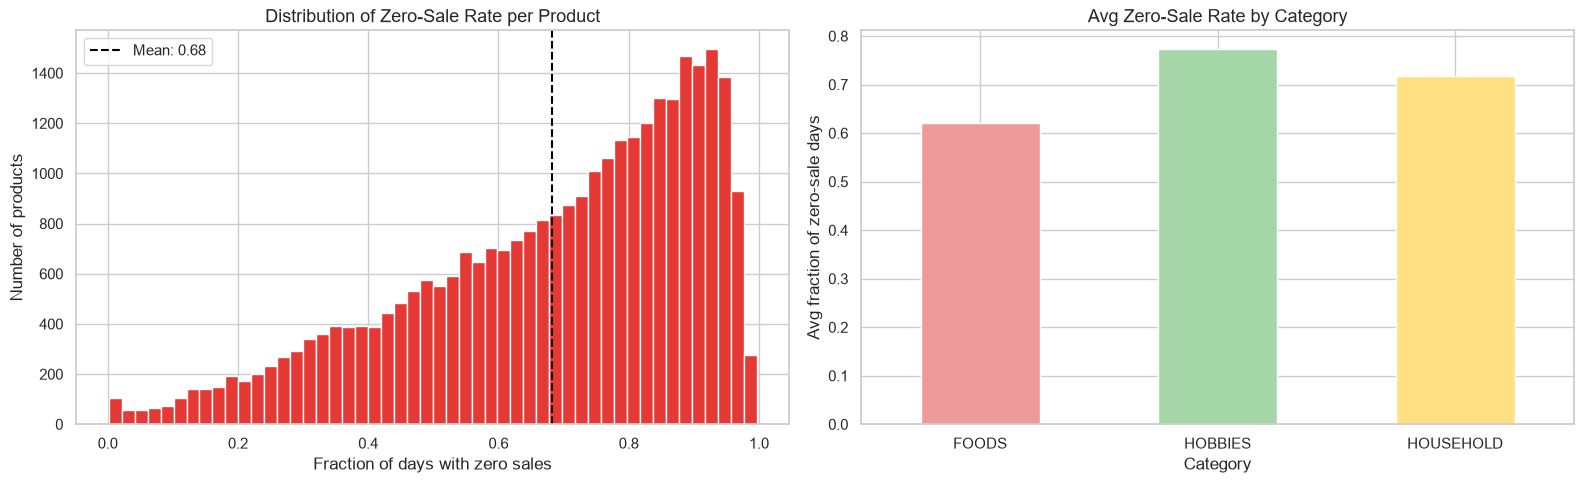


📊 Key insight: 78.4% of products have zero sales on more than half their days


In [13]:
# What % of days had zero sales per product?
day_cols_all = [col for col in sales.columns if col.startswith('d_')]
zero_rate = (sales[day_cols_all] == 0).mean(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Distribution of zero-sale rates
axes[0].hist(zero_rate, bins=50, color='#E53935', edgecolor='white')
axes[0].set_title('Distribution of Zero-Sale Rate per Product', fontsize=13)
axes[0].set_xlabel('Fraction of days with zero sales')
axes[0].set_ylabel('Number of products')
axes[0].axvline(zero_rate.mean(), color='black', linestyle='--', label=f'Mean: {zero_rate.mean():.2f}')
axes[0].legend()

# Zero rate by category
sales['zero_rate'] = zero_rate
zero_by_cat = sales.groupby('cat_id')['zero_rate'].mean()
zero_by_cat.plot(kind='bar', ax=axes[1], color=['#EF9A9A','#A5D6A7','#FFE082'])
axes[1].set_title('Avg Zero-Sale Rate by Category', fontsize=13)
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Avg fraction of zero-sale days')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('../outputs/shap_plots/02_zero_sale_rates.png', bbox_inches='tight')
plt.show()

print(f"\n📊 Key insight: {(zero_rate > 0.5).mean()*100:.1f}% of products have zero sales on more than half their days")

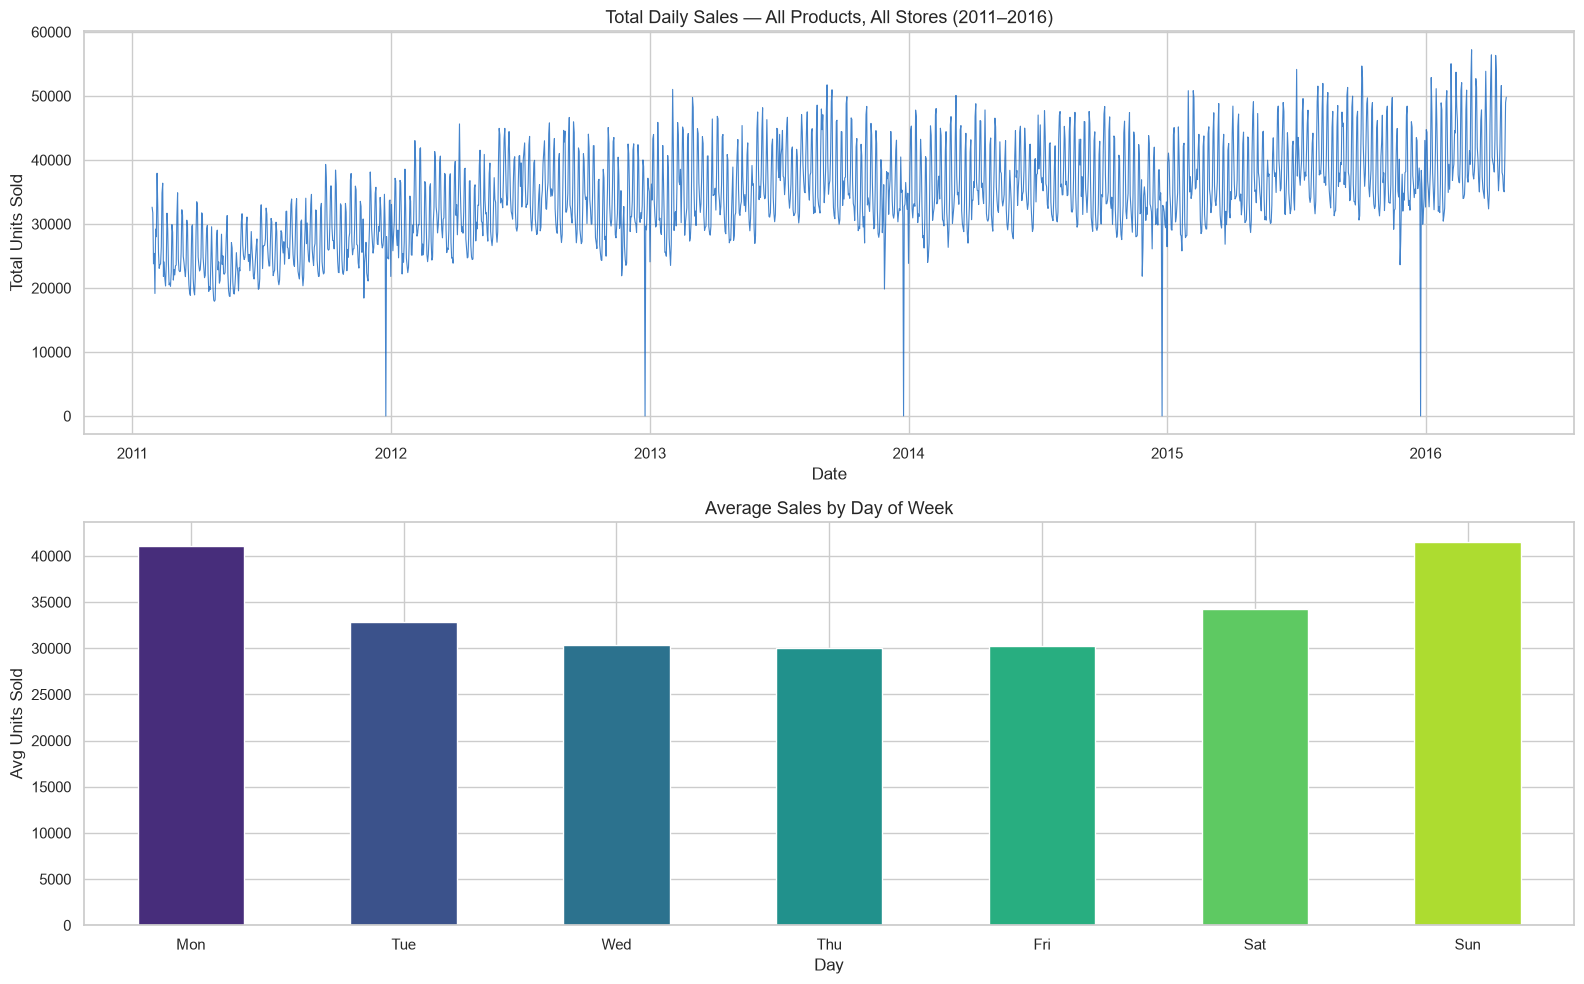

In [14]:
# Join calendar to get real dates
day_to_date = calendar[['d', 'date', 'month', 'year', 'wday']].copy()
day_to_date['date'] = pd.to_datetime(day_to_date['date'])

# Aggregate total daily sales across all products
daily_total = sales[day_cols_all].sum(axis=0).reset_index()
daily_total.columns = ['d', 'total_units']
daily_total = daily_total.merge(day_to_date, on='d')

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Plot 1 — Full time series
axes[0].plot(daily_total['date'], daily_total['total_units'], 
             color='#1565C0', linewidth=0.8, alpha=0.8)
axes[0].set_title('Total Daily Sales — All Products, All Stores (2011–2016)', fontsize=13)
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Total Units Sold')

# Plot 2 — Average by day of week
dow_map = {1:'Sun', 2:'Mon', 3:'Tue', 4:'Wed', 5:'Thu', 6:'Fri', 7:'Sat'}
daily_total['day_name'] = daily_total['wday'].map(dow_map)
dow_order = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
dow_avg = daily_total.groupby('day_name')['total_units'].mean().reindex(dow_order)
dow_avg.plot(kind='bar', ax=axes[1], color=sns.color_palette('viridis', 7))
axes[1].set_title('Average Sales by Day of Week', fontsize=13)
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Avg Units Sold')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('../outputs/shap_plots/03_seasonal_patterns.png', bbox_inches='tight')
plt.show()

In [15]:
# The full M5 dataset is too large to model in one shot during Month 1
# Strategy: pick ONE store + ONE category as your modeling target

# See which store-category combos have the most sales
store_cat = sales_long.groupby(['store_id','cat_id'])['units_sold'].sum().reset_index()
store_cat = store_cat.sort_values('units_sold', ascending=False)
print("Top 10 store-category combinations by volume:")
print(store_cat.head(10).to_string(index=False))

# Recommended subset for Month 1
TARGET_STORE = 'CA_1'
TARGET_CAT   = 'FOODS'

subset = sales[
    (sales['store_id'] == TARGET_STORE) &
    (sales['cat_id']   == TARGET_CAT)
].copy()

print(f"\n✅ Subset selected: {TARGET_STORE} × {TARGET_CAT}")
print(f"   Products in subset: {len(subset)}")
print(f"   This is {len(subset)/len(sales)*100:.1f}% of the full dataset — manageable for Month 1")

# Save subset
subset.to_csv('../data/processed/subset_CA1_FOODS.csv', index=False)
print("✅ Saved to data/processed/subset_CA1_FOODS.csv")

Top 10 store-category combinations by volume:
store_id    cat_id  units_sold
    CA_3     FOODS      364413
    WI_2     FOODS      340534
    CA_1     FOODS      264534
    WI_3     FOODS      256868
    CA_2     FOODS      251536
    TX_2     FOODS      239089
    WI_1     FOODS      237792
    TX_3     FOODS      223230
    TX_1     FOODS      182422
    CA_3 HOUSEHOLD      157128

✅ Subset selected: CA_1 × FOODS
   Products in subset: 1437
   This is 4.7% of the full dataset — manageable for Month 1
✅ Saved to data/processed/subset_CA1_FOODS.csv


In [16]:
print("=" * 55)
print("M5 EDA Summary — ExplainStock")
print("=" * 55)
print(f"""
DATASET OVERVIEW
  Total products tracked : {len(sales):,}
  Days of history        : {len(day_cols_all)} (~{len(day_cols_all)//365} years)
  States                 : {sales['state_id'].nunique()} (CA, TX, WI)
  Stores                 : {sales['store_id'].nunique()}
  Categories             : {sales['cat_id'].nunique()} (FOODS, HOBBIES, HOUSEHOLD)
  Departments            : {sales['dept_id'].nunique()}

KEY INSIGHTS
  Avg zero-sale rate     : {zero_rate.mean()*100:.1f}% of days per product
  Products >50% zeros    : {(zero_rate > 0.5).mean()*100:.1f}% of catalog
  Price range            : ${prices['sell_price'].min():.2f} – ${prices['sell_price'].max():.2f}

MONTH 1 FOCUS
  Store                  : CA_1 (highest volume)
  Category               : FOODS (highest volume)
  Subset size            : {len(subset)} products
""")
print("✅ Day 2 complete. Next: Feature Engineering (Day 3–4)")

M5 EDA Summary — ExplainStock

DATASET OVERVIEW
  Total products tracked : 30,490
  Days of history        : 1913 (~5 years)
  States                 : 3 (CA, TX, WI)
  Stores                 : 10
  Categories             : 3 (FOODS, HOBBIES, HOUSEHOLD)
  Departments            : 7

KEY INSIGHTS
  Avg zero-sale rate     : 68.2% of days per product
  Products >50% zeros    : 78.4% of catalog
  Price range            : $0.01 – $107.32

MONTH 1 FOCUS
  Store                  : CA_1 (highest volume)
  Category               : FOODS (highest volume)
  Subset size            : 1437 products

✅ Day 2 complete. Next: Feature Engineering (Day 3–4)
